# Slice-Optimization Benchmark Results

Plots for the latest `results/<run-id>/results.csv` produced by `benchmark.py`. The two knobs under test are **preemptive slice creation** (`preemptive_create_horizon_ms`) and the **slice-recycle pool** (`recycle_pool_size`); the four on/off corners isolate each effect and their interaction. VLDB/SIGMOD-style figures.

Run `pip install pandas matplotlib seaborn` if not already available.

## Reading the config columns

Each row is one benchmarked cell (one `systest -b` invocation, averaged over `runs`). The sweep is the cartesian product of:

- `query` — `SLICE_AGG` (1-day tumbling agg, ~23k live slices) or `SLICE_JOIN` (1-hour join, ~3.6k live slices).
- `preemptive_horizon_ms` — build-side lookahead. **0 = off** (no preemptive creation). With a `preemptive_predictor` it's a wall-clock horizon converted to a slice count; with `off` it's a static event-time lookahead.
- `preemptive_predictor` — watermark predictor driving the wall-clock horizon (`off` = static event-time lookahead).
- `recycle_pool_size` — LIFO of slices retired by probe-side GC, reused build-side. **0 = off**.
- `threads` — worker threads (e.g. 1 vs 16).
- `predictor` — watermark predictor for the predictive *spill* policy (`off` = plain slice store, no spill wrapper). Independent of `preemptive_predictor`.

**The 2×2 corners** (the headline): `preempt = preemptive_horizon_ms > 0`, `recycle = recycle_pool_size > 0`.

- `off/off` — baseline (neither optimization).
- `preempt` — preemptive creation only.
- `recycle` — recycle pool only.
- `both` — both on (interaction).

**Metrics** (higher = better for throughput, lower = better for time): `tuples_per_second`, `bytes_per_second`, `time_s`. Cells with a non-empty `failure_reason` have no metrics and are dropped from the accuracy plots (and tallied separately at the end).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

# Latest run by default; set RESULTS_CSV to a specific results.csv to override.
RESULTS_CSV = None
if RESULTS_CSV is None:
    candidates = sorted(Path('results').glob('*/results.csv'))
    if not candidates:
        raise FileNotFoundError('no results/<run-id>/results.csv — run benchmark.py first')
    RESULTS_CSV = candidates[-1]
csv_path = Path(RESULTS_CSV)
df = pd.read_csv(csv_path)
print('loaded', csv_path, '|', df.shape)

# Numeric coercion: failed cells leave the metric columns blank -> NaN.
for c in ['preemptive_horizon_ms', 'recycle_pool_size', 'threads', 'runs',
          'time_s', 'tuples_per_second', 'bytes_per_second']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['failure_reason'] = df['failure_reason'].fillna('')
df['failed'] = df['failure_reason'].str.len() > 0

# The 2x2 corner: each knob on iff its sentinel-0 is exceeded.
CORNER_ORDER = ['off/off', 'preempt', 'recycle', 'both']
def corner(r):
    p, rec = r['preemptive_horizon_ms'] > 0, r['recycle_pool_size'] > 0
    return {(False, False): 'off/off', (True, False): 'preempt',
            (False, True): 'recycle', (True, True): 'both'}[(p, rec)]
df['corner'] = df.apply(corner, axis=1)
df['corner'] = pd.Categorical(df['corner'], categories=CORNER_ORDER, ordered=True)
df['tps_M'] = df['tuples_per_second'] / 1e6
df['MiB_per_s'] = df['bytes_per_second'] / 2**20
FIG_DIR = csv_path.parent

# ok = scored cells only (drop failures) for the throughput/time plots.
ok = df[~df['failed']].copy()
QUERIES = sorted(df['query'].unique())
THREADS = sorted(df['threads'].dropna().unique().astype(int))
PREDICTORS = sorted(df['predictor'].unique())
PREEMPT_PREDICTORS = sorted(df['preemptive_predictor'].astype(str).unique())
HORIZONS = sorted(df['preemptive_horizon_ms'].dropna().unique().astype(int))
POOLS = sorted(df['recycle_pool_size'].dropna().unique().astype(int))

# `runs` is the number of successful repetitions averaged into each row. With one run per cell every
# bar below is a single measurement: seaborn will draw no interval, and the absence of an interval is
# not evidence of low variance. Say so rather than let a reader assume otherwise.
MAX_RUNS = int(df['runs'].max()) if df['runs'].notna().any() else 0
if MAX_RUNS < 2:
    print(f'SINGLE-RUN DATA (runs={MAX_RUNS}): no confidence intervals are computable. Raise '
          f'RUNS_PER_CELL in benchmark.py to >=3 before quoting any of these numbers as a result.')

print('queries:', QUERIES, '| threads:', THREADS, '| predictors:', PREDICTORS,
      '| preemptive predictors:', PREEMPT_PREDICTORS, '| horizons:', HORIZONS, '| pools:', POOLS,
      '| failed:', int(df['failed'].sum()), '/', len(df))
ok.head()

loaded results/00000000-000000-SYNTHETIC-LAYOUT-ONLY/results.csv | (128, 13)
SINGLE-RUN DATA (runs=1): no confidence intervals are computable. Raise RUNS_PER_CELL in benchmark.py to >=3 before quoting any of these numbers as a result.
queries: ['CM_AGG', 'CM_JOIN'] | threads: [1, 16] | predictors: ['ewma', 'kalman', 'off', 'robustkalman'] | preemptive predictors: ['off', 'robustkalman'] | horizons: [0, 1000] | pools: [0, 4096] | failed: 1 / 128


,run_id,query,preemptive_horizon_ms,preemptive_predictor,preemptive_max_slices,recycle_pool_size,threads,predictor,runs,time_s,tuples_per_second,bytes_per_second,failure_reason,failed,corner,tps_M,MiB_per_s
0,00000000-000000-SYNTHETIC-LAYOUT-ONLY,CM_AGG,0,off,256,0,1,off,1,1579.179,2.596286e+06,1.246217e+08,,False,off/off,2.596286,118.848523
1,00000000-000000-SYNTHETIC-LAYOUT-ONLY,CM_AGG,0,off,256,0,1,ewma,1,1590.000,2.578616e+06,1.237735e+08,,False,off/off,2.578616,118.039656
2,00000000-000000-SYNTHETIC-LAYOUT-ONLY,CM_AGG,0,off,256,0,1,kalman,1,1577.616,2.598858e+06,1.247452e+08,,False,off/off,2.598858,118.966291
3,00000000-000000-SYNTHETIC-LAYOUT-ONLY,CM_AGG,0,off,256,0,1,robustkalman,1,1604.217,2.555764e+06,1.226767e+08,,False,off/off,2.555764,116.993572
4,00000000-000000-SYNTHETIC-LAYOUT-ONLY,CM_AGG,0,off,256,0,16,off,1,213.048,1.924453e+07,9.237372e+08,,False,off/off,19.244526,880.944488


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# VLDB / SIGMOD camera-ready style: serif, compact, no chartjunk.
sns.set_theme(context='paper', style='whitegrid', font='serif')
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 11,
    'axes.labelsize': 11,
    'axes.titleweight': 'bold',
    'legend.fontsize': 9,
    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.4,
})
CORNER_PALETTE = dict(zip(CORNER_ORDER, sns.color_palette('tab10', 4)))
PRED_PALETTE = dict(zip(PREDICTORS, sns.color_palette('Set2', len(PREDICTORS))))
PREEMPT_PALETTE = dict(zip(PREEMPT_PREDICTORS, sns.color_palette('Dark2', len(PREEMPT_PREDICTORS))))

# With a single run per cell there is nothing to build an interval from; asking seaborn for one just
# costs a bootstrap. With repetitions, show a 95% CI.
ERRORBAR = ('ci', 95) if MAX_RUNS >= 2 else None


def save(fig, name):
    """Write the figure next to the run's results.csv. This notebook previously had no savefig at
    all, so none of its figures could be regenerated for a paper."""
    out = FIG_DIR / f'{name}.png'
    fig.savefig(out, bbox_inches='tight')
    print('wrote', out)


print('style ready | errorbar:', ERRORBAR)

style ready | errorbar: None


## 1. The 2×2 corners — throughput
Mean tuples/s for each on/off corner, one panel per query, bars grouped by thread count. This is the headline: does turning on preemptive creation and/or the recycle pool move throughput, and do they compound? Averages over the predictor settings — the per-predictor breakdown is in §4.

wrote results/00000000-000000-SYNTHETIC-LAYOUT-ONLY/fig_00_corners.png


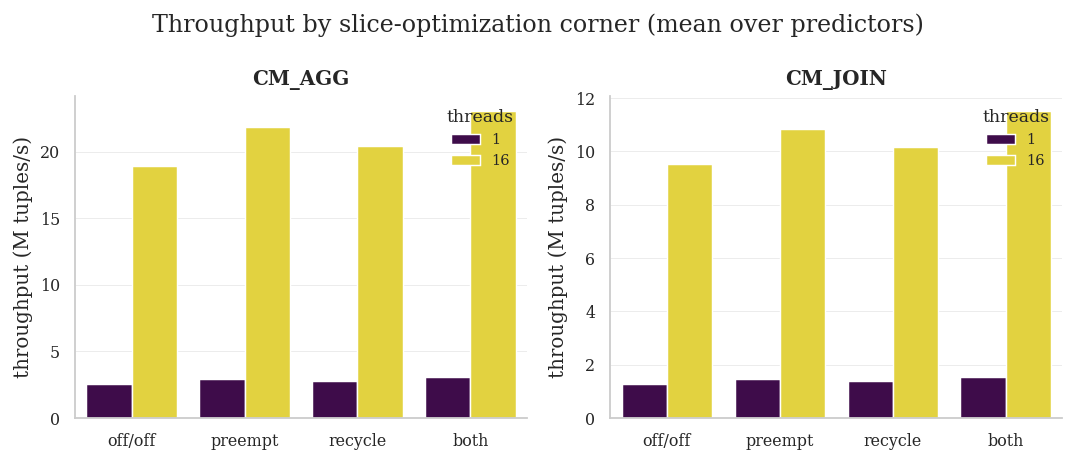

In [3]:
fig, axes = plt.subplots(1, len(QUERIES), figsize=(4.2 * len(QUERIES), 3.6), squeeze=False)
for ax, q in zip(axes[0], QUERIES):
    sub = ok[ok['query'] == q]
    sns.barplot(sub, x='corner', y='tps_M', hue='threads', order=CORNER_ORDER,
                palette='viridis', errorbar=ERRORBAR, ax=ax)
    ax.set_title(q)
    ax.set_xlabel('')
    ax.set_ylabel('throughput (M tuples/s)')
    ax.legend(title='threads', fontsize=8)
fig.suptitle('Throughput by slice-optimization corner (mean over predictors)')
fig.tight_layout()
save(fig, 'fig_00_corners')
plt.show()

## 2. Speedup over the off/off baseline
Each corner's throughput divided by the `off/off` baseline at the **same** (query, threads, preemptive_predictor, predictor) cell, so only the two slice knobs vary. >1 = faster than baseline. The dashed line is parity.

wrote results/00000000-000000-SYNTHETIC-LAYOUT-ONLY/fig_01_speedup.png


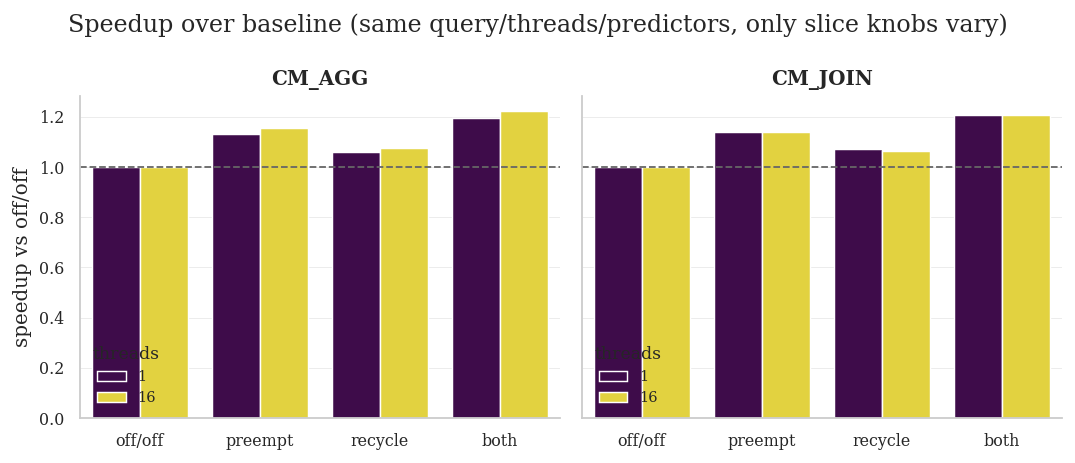

In [4]:
# Join each scored cell to its off/off twin (same everything except the two knobs).
KEY = ['query', 'threads', 'preemptive_predictor', 'predictor']
base = (ok[ok['corner'] == 'off/off']
        .groupby(KEY, as_index=False)['tuples_per_second'].mean()
        .rename(columns={'tuples_per_second': 'base_tps'}))
sp = ok.merge(base, on=KEY, how='left')
sp['speedup'] = sp['tuples_per_second'] / sp['base_tps']
sp = sp[sp['base_tps'].notna()]

fig, axes = plt.subplots(1, len(QUERIES), figsize=(4.2 * len(QUERIES), 3.6), squeeze=False, sharey=True)
for ax, q in zip(axes[0], QUERIES):
    sns.barplot(sp[sp['query'] == q], x='corner', y='speedup', hue='threads',
                order=CORNER_ORDER, palette='viridis', errorbar=ERRORBAR, ax=ax)
    ax.axhline(1.0, ls='--', lw=1, color='0.4')
    ax.set_title(q)
    ax.set_xlabel('')
    ax.set_ylabel('speedup vs off/off')
    ax.legend(title='threads', fontsize=8)
fig.suptitle('Speedup over baseline (same query/threads/predictors, only slice knobs vary)')
fig.tight_layout()
save(fig, 'fig_01_speedup')
plt.show()

## 3. Thread scaling
Throughput vs worker threads, one line per corner, one panel per query. Does either optimization improve how the slice store scales with parallelism?

wrote results/00000000-000000-SYNTHETIC-LAYOUT-ONLY/fig_02_scaling.png


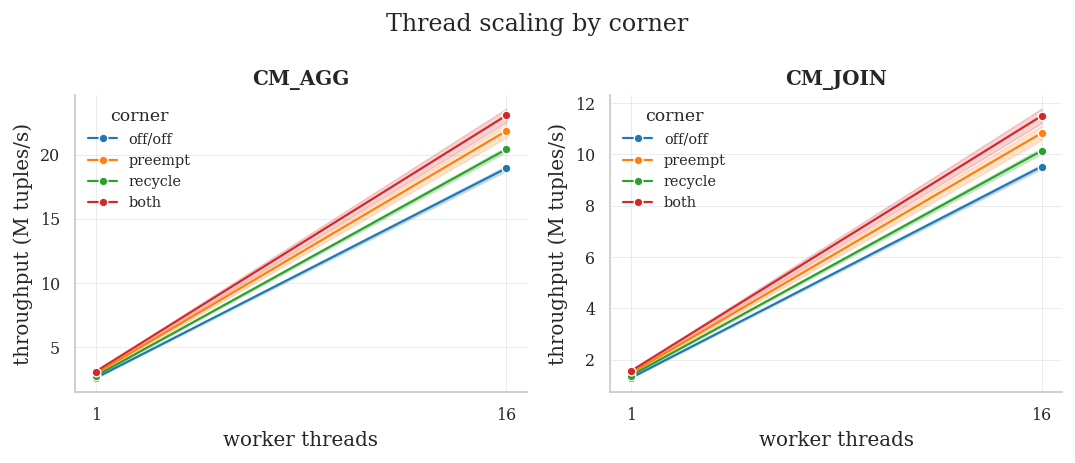

In [5]:
fig, axes = plt.subplots(1, len(QUERIES), figsize=(4.2 * len(QUERIES), 3.6), squeeze=False)
for ax, q in zip(axes[0], QUERIES):
    sns.lineplot(ok[ok['query'] == q], x='threads', y='tps_M', hue='corner',
                 hue_order=CORNER_ORDER, palette=CORNER_PALETTE, marker='o', errorbar='sd', ax=ax)
    ax.set_title(q)
    ax.set_xlabel('worker threads')
    ax.set_ylabel('throughput (M tuples/s)')
    ax.set_xticks(THREADS)
    ax.legend(title='corner', fontsize=8)
fig.suptitle('Thread scaling by corner')
fig.tight_layout()
save(fig, 'fig_02_scaling')
plt.show()

## 4. Predictor breakdown
Throughput per spill `predictor` (`off` = no spill wrapper), grouped by corner, one panel per query at the highest thread count. Shows whether a given predictor's spill policy interacts with the slice knobs.

wrote results/00000000-000000-SYNTHETIC-LAYOUT-ONLY/fig_03_spill_predictor.png


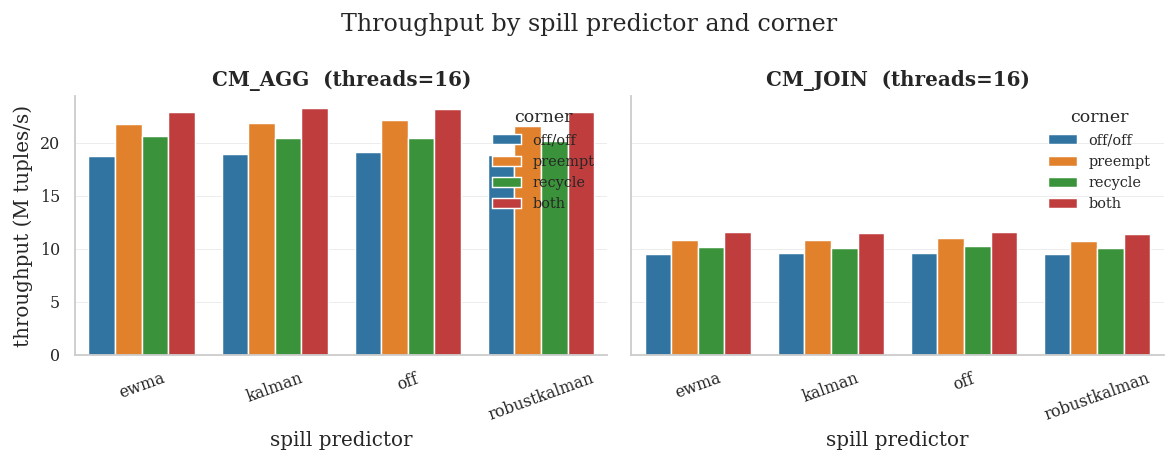

In [6]:
tmax = max(THREADS) if THREADS else None
fig, axes = plt.subplots(1, len(QUERIES), figsize=(4.6 * len(QUERIES), 3.6), squeeze=False, sharey=True)
for ax, q in zip(axes[0], QUERIES):
    sub = ok[(ok['query'] == q) & (ok['threads'] == tmax)]
    sns.barplot(sub, x='predictor', y='tps_M', hue='corner', order=PREDICTORS,
                hue_order=CORNER_ORDER, palette=CORNER_PALETTE, errorbar=ERRORBAR, ax=ax)
    ax.set_title(f'{q}  (threads={tmax})')
    ax.set_xlabel('spill predictor')
    ax.set_ylabel('throughput (M tuples/s)')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='corner', fontsize=8)
fig.suptitle('Throughput by spill predictor and corner')
fig.tight_layout()
save(fig, 'fig_03_spill_predictor')
plt.show()

## 5. Full-sweep heatmap
Every config cell × query, throughput in M tuples/s. The config label is the benchmark slug: `h<horizon>_pp<preemptive_predictor>_p<pool>_t<threads>_<predictor>`. Color is normalized per column (per query) so each query's best/worst spread is visible; the annotation is the raw value. Failed cells show as blank.

wrote results/00000000-000000-SYNTHETIC-LAYOUT-ONLY/fig_06_heatmap_absolute.png


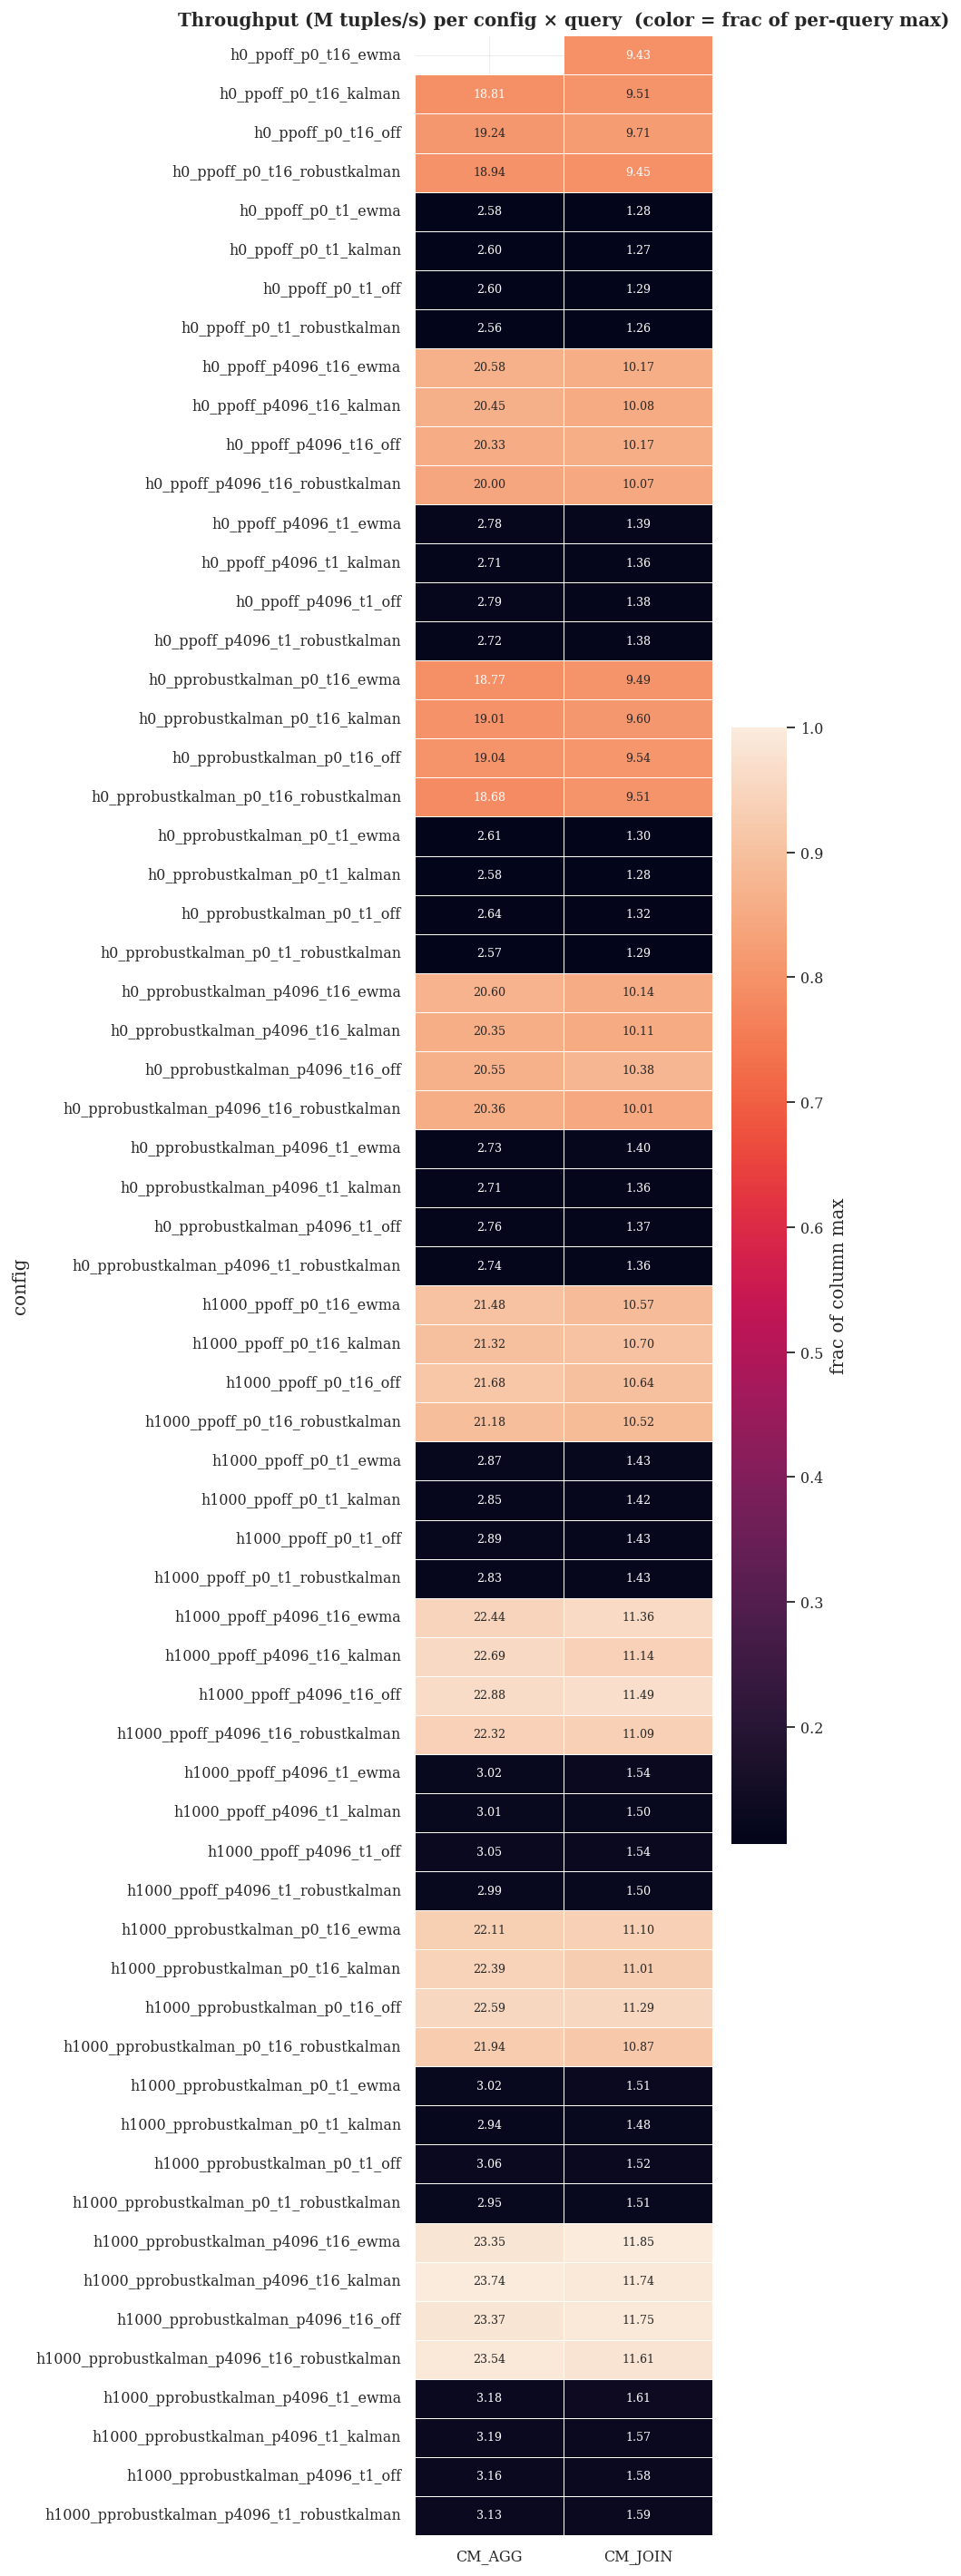

In [7]:
df['config'] = (
    'h' + df['preemptive_horizon_ms'].astype('Int64').astype(str)
    + '_pp' + df['preemptive_predictor'].astype(str)
    + '_p' + df['recycle_pool_size'].astype('Int64').astype(str)
    + '_t' + df['threads'].astype('Int64').astype(str)
    + '_' + df['predictor'].astype(str)
)
pivot = df.pivot_table(index='config', columns='query', values='tps_M', sort=True)
norm = pivot.div(pivot.max(axis=0), axis=1)  # per-query (column) normalization
fig, ax = plt.subplots(figsize=(2.2 * len(QUERIES) + 3, 0.32 * len(pivot) + 1.5))
sns.heatmap(norm, annot=pivot, fmt='.2f', cmap='rocket', linewidths=0.4,
            annot_kws={'fontsize': 7}, cbar_kws={'label': 'frac of column max'}, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('config')
ax.set_title('Throughput (M tuples/s) per config × query  (color = frac of per-query max)')
fig.tight_layout()
save(fig, 'fig_06_heatmap_absolute')
plt.show()

## 6. Failures
Cells that didn't produce a result, by reason. Empty table = clean sweep.

In [8]:
fails = df[df['failed']][['query', 'corner', 'threads', 'preemptive_predictor', 'predictor', 'failure_reason']]
print(f'{len(fails)} failed / {len(df)} cells')
if len(fails):
    display(fails.reset_index(drop=True))
    print('\nby reason:')
    print(fails['failure_reason'].value_counts())

1 failed / 128 cells


,query,corner,threads,preemptive_predictor,predictor,failure_reason
0,CM_AGG,off/off,16,off,ewma,systest timeout (1800s)



by reason:
failure_reason
systest timeout (1800s)    1
Name: count, dtype: int64


## 6. Latency and byte throughput

`time_s` and `bytes_per_second` are both collected and documented at the top of this notebook, and
until now neither appeared in a figure — every plot used `tuples_per_second`.

They are not redundant with it. `time_s` is the number a user feels (wall time to drain the input),
and `bytes_per_second` differs from tuples/s whenever the queries have different tuple widths, which
`CM_AGG` and `CM_JOIN` do. If preemptive creation moves allocation off the critical path, wall time
should fall even where the tuple rate looks flat.

wrote results/00000000-000000-SYNTHETIC-LAYOUT-ONLY/fig_04_latency_and_bytes.png


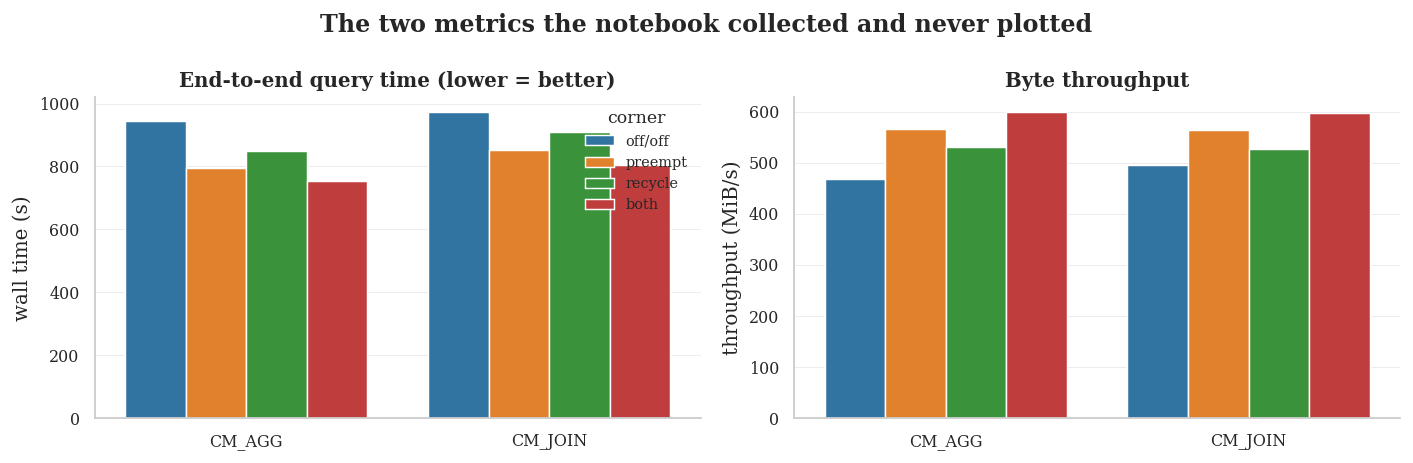

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
sns.barplot(ok, x='query', y='time_s', hue='corner', hue_order=CORNER_ORDER,
            palette=CORNER_PALETTE, errorbar=ERRORBAR, ax=axes[0])
axes[0].set_ylabel('wall time (s)')
axes[0].set_xlabel('')
axes[0].set_title('End-to-end query time (lower = better)')

sns.barplot(ok, x='query', y='MiB_per_s', hue='corner', hue_order=CORNER_ORDER,
            palette=CORNER_PALETTE, errorbar=ERRORBAR, ax=axes[1])
axes[1].set_ylabel('throughput (MiB/s)')
axes[1].set_xlabel('')
axes[1].set_title('Byte throughput')
if axes[1].get_legend():
    axes[1].get_legend().remove()
axes[0].legend(title='corner', fontsize=8)

fig.suptitle('The two metrics the notebook collected and never plotted', fontweight='bold')
fig.tight_layout()
save(fig, 'fig_04_latency_and_bytes')
plt.show()

## 7. Does a better predictor buy better preemptive creation?

`preemptive_predictor` is a swept axis (`off` vs `robustkalman`) that has appeared in no figure —
only as a join key and inside the heatmap's config label. But it *is* the question this benchmark
exists to answer: preemptive creation asks the watermark predictor when a slice will be needed, so
the predictor's quality should show up as throughput.

Left: throughput by preemptive predictor, split by corner. `off/off` and `recycle` are the controls
— the predictor is not consulted there, so those bars must be flat across predictors; any spread in
them is measurement noise and calibrates how much of the `preempt`/`both` spread is real.

Right: horizon sensitivity. A horizon of 0 disables preemption entirely.

wrote results/00000000-000000-SYNTHETIC-LAYOUT-ONLY/fig_05_preemptive_predictor.png


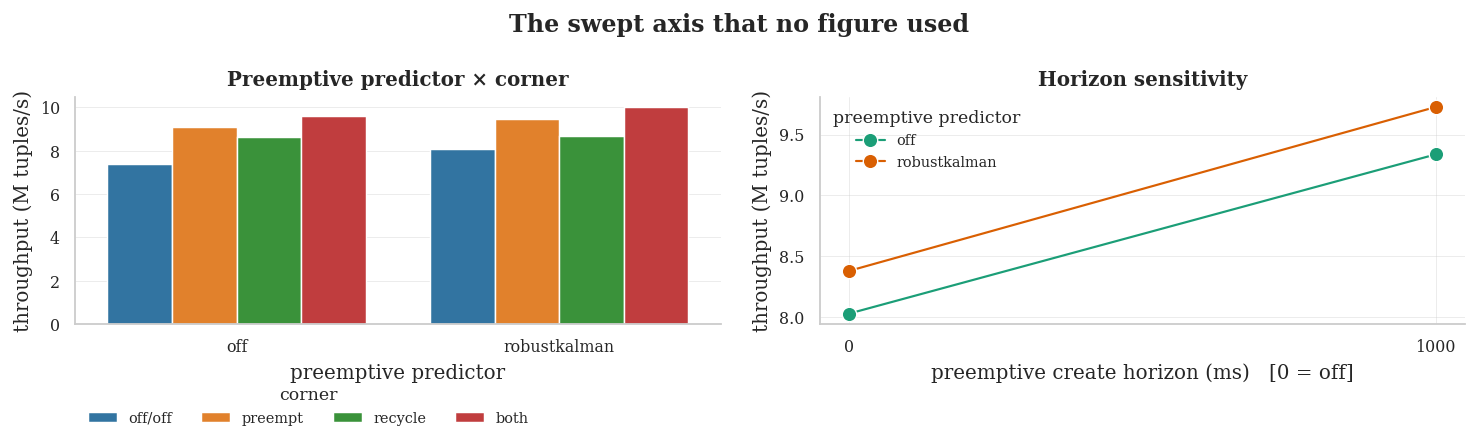

recycle-pool sensitivity skipped: RECYCLE_POOL_SIZE is swept over [0, 4096] (on/off only). Add intermediate sizes in benchmark.py to plot a curve.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.7))

sns.barplot(ok, x='preemptive_predictor', y='tps_M', hue='corner', hue_order=CORNER_ORDER,
            order=PREEMPT_PREDICTORS, palette=CORNER_PALETTE, errorbar=ERRORBAR, ax=axes[0])
axes[0].set_xlabel('preemptive predictor')
axes[0].set_ylabel('throughput (M tuples/s)')
axes[0].set_title('Preemptive predictor × corner')
### Outside the axes: with four corners the in-axes legend lands on the last bar group.
axes[0].legend(title='corner', fontsize=8, loc='upper left', bbox_to_anchor=(0.0, -0.22), ncol=4)

if len(HORIZONS) > 1:
    sns.lineplot(ok, x='preemptive_horizon_ms', y='tps_M', hue='preemptive_predictor',
                 hue_order=PREEMPT_PREDICTORS, palette=PREEMPT_PALETTE, marker='o',
                 markersize=8, errorbar=ERRORBAR, ax=axes[1])
    axes[1].set_xticks(HORIZONS)
    axes[1].legend(title='preemptive predictor', fontsize=8)
else:
    axes[1].text(0.5, 0.5,
                 f'PREEMPTIVE_HORIZON_MS is swept over {HORIZONS} only.\n'
                 'Sensitivity needs >=3 levels — widen the sweep\nin benchmark.py.',
                 ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_xlabel('preemptive create horizon (ms)   [0 = off]')
axes[1].set_ylabel('throughput (M tuples/s)')
axes[1].set_title('Horizon sensitivity')

fig.suptitle('The swept axis that no figure used', fontweight='bold')
fig.tight_layout()
save(fig, 'fig_05_preemptive_predictor')
plt.show()

### Same question for the recycle pool, which is likewise swept on/off only.
if len(POOLS) > 2:
    fig, ax = plt.subplots(figsize=(6, 3.6))
    sns.lineplot(ok, x='recycle_pool_size', y='tps_M', hue='query', marker='o',
                 markersize=8, errorbar=ERRORBAR, ax=ax)
    ax.set_xlabel('recycle pool size   [0 = off]')
    ax.set_ylabel('throughput (M tuples/s)')
    ax.set_title('Recycle-pool sensitivity')
    fig.tight_layout()
    save(fig, 'fig_05b_recycle_pool')
    plt.show()
else:
    print(f'recycle-pool sensitivity skipped: RECYCLE_POOL_SIZE is swept over {POOLS} '
          f'(on/off only). Add intermediate sizes in benchmark.py to plot a curve.')

## 8. What does running a predictor cost when it never spills?

`benchmark.py`'s docstring documents an experiment that no figure has ever shown: run with
`--high-bound` above 1.0, so the pressure threshold is unreachable. The spill predictor is
constructed, observed on every GC tick and queried for every slice — but nothing is ever written.
The gap to `predictor=off` is therefore the **pure cost of the predictor on the critical path**,
with the I/O and the eviction-quality effects removed.

This cell only produces a figure for runs that contain such cells; it prints how to generate them
otherwise.

In [11]:
### The unreachable-threshold cells are the ones where a predictor is configured but nothing spills.
### They are only distinguishable if the run was produced with --high-bound > 1.0; the column is not
### in results.csv, so identify them by the run's own provenance instead of guessing.
HIGH_BOUND_RUN = None   # set to True if this results dir came from a --high-bound > 1.0 sweep

if HIGH_BOUND_RUN is None:
    print('Set HIGH_BOUND_RUN = True if this run was produced with --high-bound > 1.0.\n'
          'To generate it (from the repo root):\n'
          '  ./scripts/benchmarking/slice_optimization_benchmarks/run.sh \\\n'
          '      --high-bound 2.0 --horizon 0 --pool 0 --predictor off,ewma,kalman,robustkalman\n'
          'That pins both slice knobs off so the only difference between cells is which spill\n'
          'predictor runs — and none of them ever spills.')
else:
    over = ok[ok['threads'] == max(THREADS)]
    base = (over[over['predictor'] == 'off']
            .groupby(['query', 'threads'], as_index=False)['tuples_per_second']
            .mean().rename(columns={'tuples_per_second': 'base_tps'}))
    over = over.merge(base, on=['query', 'threads'], how='left')
    over['rel'] = over['tuples_per_second'] / over['base_tps']

    fig, ax = plt.subplots(figsize=(7, 3.6))
    sns.barplot(over[over['predictor'] != 'off'], x='predictor', y='rel', hue='query',
                order=[p for p in PREDICTORS if p != 'off'], errorbar=ERRORBAR, ax=ax)
    ax.axhline(1.0, ls='--', lw=1, color='0.4')
    ax.set_xlabel('spill predictor (never spills — threshold unreachable)')
    ax.set_ylabel('throughput relative to predictor=off')
    ax.set_title('Pure predictor overhead on the critical path')
    ax.tick_params(axis='x', rotation=20)
    fig.tight_layout()
    save(fig, 'fig_07_predictor_overhead')
    plt.show()

Set HIGH_BOUND_RUN = True if this run was produced with --high-bound > 1.0.
To generate it (from the repo root):
  ./scripts/benchmarking/slice_optimization_benchmarks/run.sh \
      --high-bound 2.0 --horizon 0 --pool 0 --predictor off,ewma,kalman,robustkalman
That pins both slice knobs off so the only difference between cells is which spill
predictor runs — and none of them ever spills.


## 9. The sweep relative to the baseline

The heatmap in §5 normalizes each column to its own maximum, which answers "which config was best
for this query" but not "did this config beat not optimizing at all" — the fastest cell is coloured
1.00 whether it is 3× the baseline or 3% below it.

This one divides by the matched `off/off` cell and uses a diverging scale centred on 1.0: blue beats
the baseline, red is worse than it.

wrote results/00000000-000000-SYNTHETIC-LAYOUT-ONLY/fig_08_heatmap_vs_baseline.png


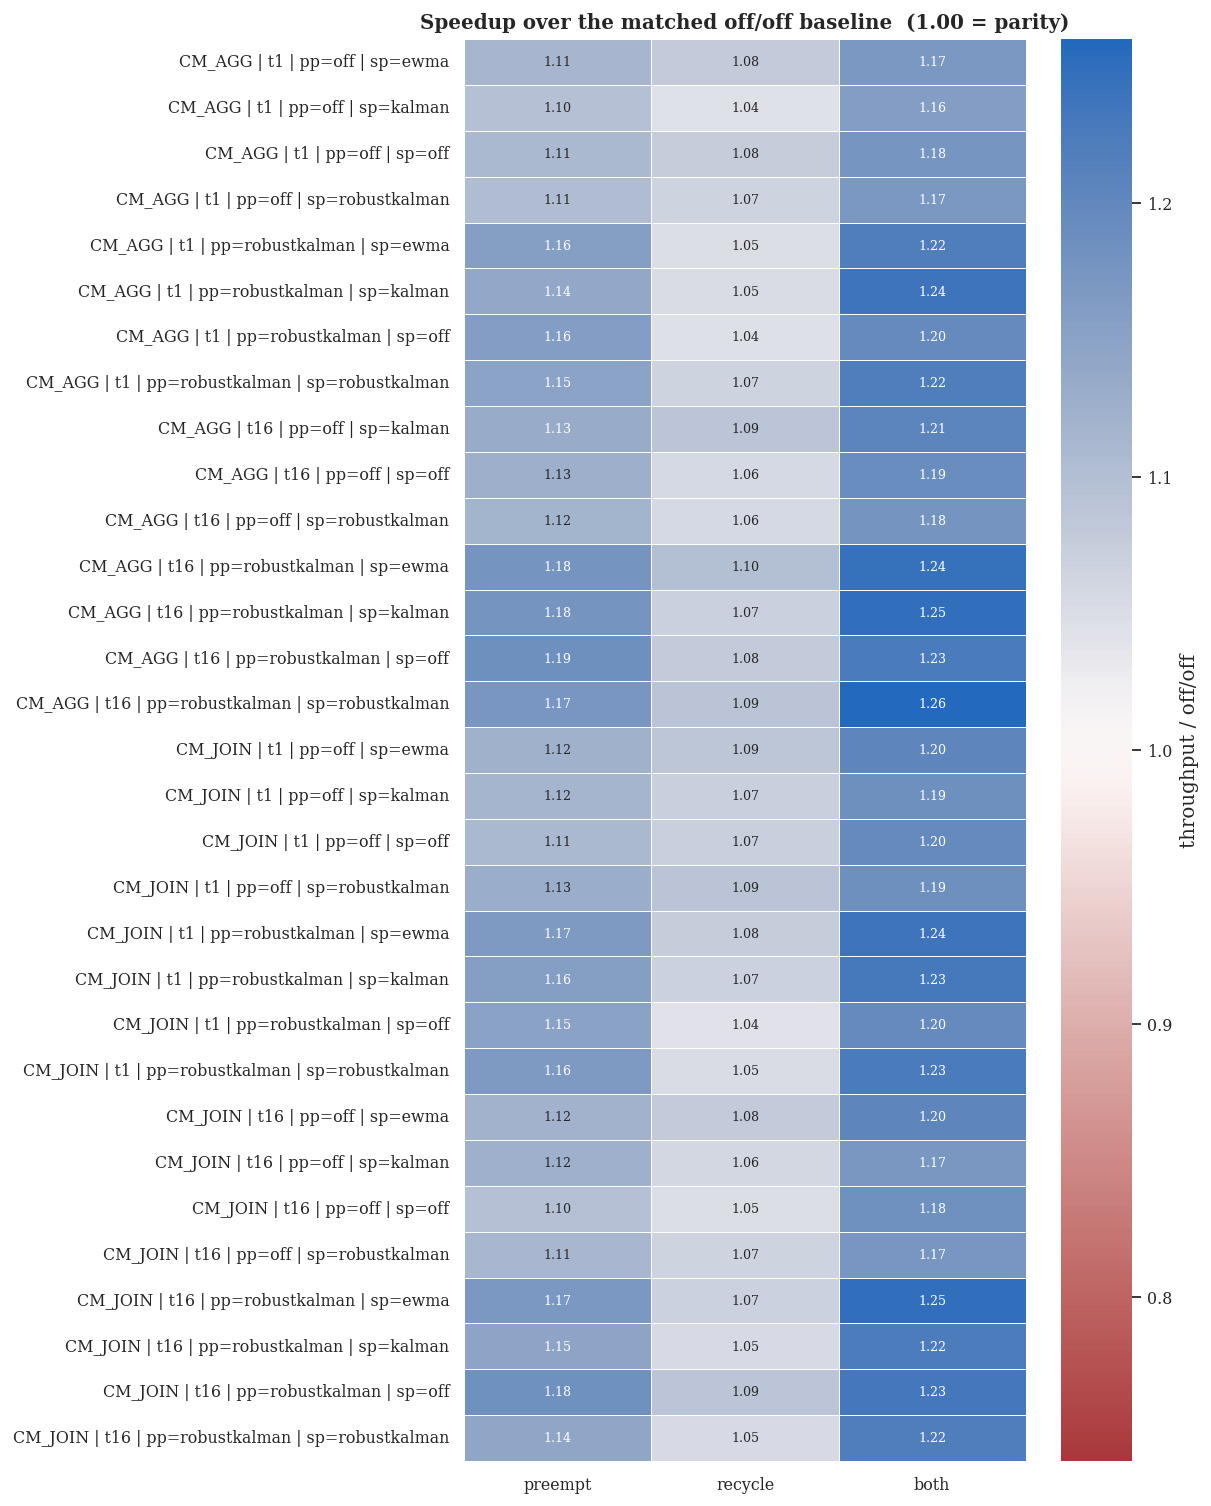

In [12]:
from matplotlib.colors import TwoSlopeNorm

KEY = ['query', 'threads', 'preemptive_predictor', 'predictor']
base = (ok[ok['corner'] == 'off/off']
        .groupby(KEY, as_index=False)['tuples_per_second'].mean()
        .rename(columns={'tuples_per_second': 'base_tps'}))
rel = ok.merge(base, on=KEY, how='left')
rel = rel[rel['base_tps'].notna() & (rel['corner'] != 'off/off')].copy()
rel['speedup'] = rel['tuples_per_second'] / rel['base_tps']

if len(rel) == 0:
    print('skipped: no cell has an off/off twin to normalize against')
else:
    ### Row = everything except the two slice knobs; column = the corner those knobs select.
    rel['config'] = (rel['query'].astype(str)
                     + ' | t' + rel['threads'].astype('Int64').astype(str)
                     + ' | pp=' + rel['preemptive_predictor'].astype(str)
                     + ' | sp=' + rel['predictor'].astype(str))
    pivot = rel.pivot_table(index='config', columns='corner', values='speedup', observed=True)
    span = float(np.nanmax(np.abs(pivot.to_numpy() - 1.0)))
    norm = TwoSlopeNorm(vmin=1 - span, vcenter=1.0, vmax=1 + span) if span > 0 else None
    fig, ax = plt.subplots(figsize=(1.4 * pivot.shape[1] + 5, 0.32 * len(pivot) + 1.8))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='vlag_r', norm=norm, linewidths=0.4,
                annot_kws={'fontsize': 7}, cbar_kws={'label': 'throughput / off/off'}, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('Speedup over the matched off/off baseline  (1.00 = parity)')
    fig.tight_layout()
    save(fig, 'fig_08_heatmap_vs_baseline')
    plt.show()

## 10. What this benchmark cannot currently show

Recorded here so a reader does not infer more from the figures than the data supports.

* **No memory or slice-count metric exists.** `BenchmarkResult` (`nes-systests/systest/include/SystestRunner.hpp`)
  carries only `time`, `tuplesPerSecond` and `bytesPerSecond`. The mechanism claim — that preemptive
  creation removes allocation from the critical path and that the recycle pool cuts slice
  churn — is therefore supported only *indirectly*, by throughput. Allocation counts, live-slice
  counts or a preemption hit rate would make it direct; the spilling benchmark grew exactly this
  kind of counter (`spill_stats.csv`) and the same treatment would apply here.
* **Both slice knobs are swept on/off only** (`PREEMPTIVE_HORIZON_MS = [0, 1000]`,
  `RECYCLE_POOL_SIZE = [0, 4096]`), so §7 can show a difference but not a shape.
* **`PREEMPTIVE_MAX_SLICES` is a constant** (256), not an axis, although it bounds exactly what
  preemptive creation is allowed to do.
* **`RUNS_PER_CELL = 1`**, so no figure here carries an interval. See the warning printed by the
  loader.